
# Analisis Keterhubungan dan Jalur Terpendek pada Jaringan GitHub Menggunakan Algoritma Breadth-First Search (BFS)




##Flowchart
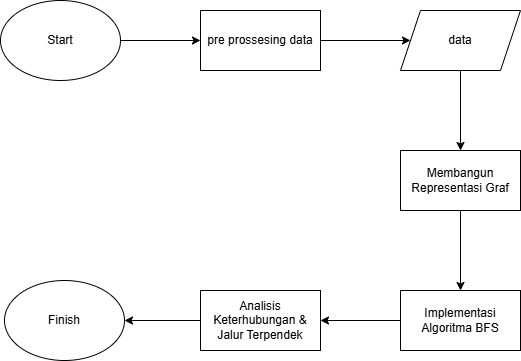

In [20]:

from collections import deque
from pathlib import Path
import pandas as pd



## 1. Memuat Data




In [21]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')
# Load data edge list
edges_path = "/content/drive/MyDrive/JST/musae_git_edges.csv"
df_edges = pd.read_csv(edges_path)

print("Jumlah edge:", len(df_edges))
df_edges.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah edge: 289003


,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


## 2. Pra-pemrosesan Data

Tahap ini membersihkan data agar sesuai dengan metode penelitian.

In [22]:

# Pastikan nama kolom sesuai
expected_cols = {'id_1', 'id_2'}
if not expected_cols.issubset(df_edges.columns):
    raise ValueError(f"Kolom dataset harus memuat {expected_cols}, tetapi yang ditemukan: {list(df_edges.columns)}")

# Ambil hanya kolom yang diperlukan
edges_clean = df_edges[['id_1', 'id_2']].copy()

# Hapus baris kosong
edges_clean = edges_clean.dropna()

# Ubah tipe data ke integer
edges_clean['id_1'] = edges_clean['id_1'].astype(int)
edges_clean['id_2'] = edges_clean['id_2'].astype(int)

# Hapus self-loop (node terhubung ke dirinya sendiri)
edges_clean = edges_clean[edges_clean['id_1'] != edges_clean['id_2']]

# Untuk graf tak berarah, pasangan (u, v) dan (v, u) dianggap sama
edges_clean[['u', 'v']] = pd.DataFrame(
    edges_clean.apply(lambda row: sorted((row['id_1'], row['id_2'])), axis=1).tolist(),
    index=edges_clean.index
)
edges_clean = edges_clean[['u', 'v']].drop_duplicates().reset_index(drop=True)

print(f"Jumlah edge setelah cleaning: {len(edges_clean):,}")
print(f"Jumlah node unik: {pd.unique(edges_clean[['u', 'v']].values.ravel()).size:,}")
edges_clean.head()


Jumlah edge setelah cleaning: 289,003
Jumlah node unik: 37,700


,u,v
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


## 3. Membangun Graf

Graf dibentuk sebagai **adjacency list** agar efisien untuk implementasi BFS.

In [23]:

def build_graph_from_edges(df, col_u='u', col_v='v', undirected=True):
    graph = {}

    for u, v in zip(df[col_u], df[col_v]):
        graph.setdefault(u, set()).add(v)
        graph.setdefault(v, set())
        if undirected:
            graph.setdefault(v, set()).add(u)
            graph.setdefault(u, set())

    # Ubah set menjadi list terurut agar hasil BFS konsisten
    return {node: sorted(neighbors) for node, neighbors in graph.items()}


graph = build_graph_from_edges(edges_clean)

print(f"Jumlah node dalam graph: {len(graph):,}")
print(f"Contoh 5 node pertama: {list(graph.items())[:5]}")


Jumlah node dalam graph: 37,700
Contoh 5 node pertama: [(0, [23977]), (23977, [0, 69, 1966, 2939, 3147, 4422, 5631, 5895, 8973, 9212, 10081, 10111, 11305, 12114, 13060, 14480, 15313, 16972, 17127, 18520, 19222, 19375, 25285, 25477, 25679, 27803, 29188, 29826, 30863, 31890, 33206, 35828]), (1, [2370, 14683, 20363, 21142, 23830, 29982, 34035, 34526]), (34526, [1, 23589]), (2370, [1, 184, 1164, 1213, 2979, 3226, 5348, 6847, 9465, 10787, 11279, 12859, 13887, 14400, 14712, 15066, 16431, 19477, 20469, 21550, 22642, 23209, 23297, 23484, 23767, 23837, 25576, 25638, 26293, 26647, 27803, 27828, 29982, 31890, 32202, 32819, 34689, 34840, 34849, 36788])]


## 4. Implementasi Algoritma Breadth-First Search (BFS)

In [24]:

def bfs_shortest_path(graph, start_node, target_node=None):
    """
    BFS untuk:
    1) mengecek keterjangkauan node,
    2) mencari jalur terpendek pada graf tak berbobot,
    3) menghitung jarak dari start_node ke node lain.
    """
    if start_node not in graph:
        raise ValueError(f"Node {start_node} tidak ada di graph.")

    queue = deque([start_node])
    visited = {start_node}
    parent = {start_node: None}
    distance = {start_node: 0}
    visit_order = []

    while queue:
        current = queue.popleft()
        visit_order.append(current)

        if target_node is not None and current == target_node:
            break

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                distance[neighbor] = distance[current] + 1
                queue.append(neighbor)

    # Jika target ditentukan tetapi tidak ditemukan
    if target_node is not None and target_node not in visited:
        return {
            'found': False,
            'path': None,
            'distance': None,
            'visited_count': len(visited),
            'visit_order': visit_order,
            'reachable_nodes': visited
        }

    # Rekonstruksi jalur jika target ditemukan
    path = None
    if target_node is not None:
        path = []
        node = target_node
        while node is not None:
            path.append(node)
            node = parent[node]
        path.reverse()

    return {
        'found': True,
        'path': path,
        'distance': distance.get(target_node) if target_node is not None else distance,
        'visited_count': len(visited),
        'visit_order': visit_order,
        'reachable_nodes': visited
    }


## 5. Analisis Keterhubungan Jaringan

Untuk melihat apakah graf terhubung secara global atau terbagi menjadi beberapa komponen terhubung.

In [25]:

def connected_components_bfs(graph):
    """Mengembalikan daftar komponen terhubung menggunakan BFS."""
    unvisited = set(graph.keys())
    components = []

    while unvisited:
        start = next(iter(unvisited))
        result = bfs_shortest_path(graph, start)
        component = sorted(result['reachable_nodes'])
        components.append(component)
        unvisited -= set(component)

    return components


components = connected_components_bfs(graph)
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Jumlah komponen terhubung: {len(components):,}")
print(f"Ukuran 5 komponen terbesar: {component_sizes[:5]}")
print("Apakah graph terhubung secara global?", "Ya" if len(components) == 1 else "Tidak")


Jumlah komponen terhubung: 1
Ukuran 5 komponen terbesar: [37700]
Apakah graph terhubung secara global? Ya


## 6. Analisis Jalur Terpendek Antar Simpul

Pilih dua node untuk melihat hasil BFS secara langsung.

In [26]:

# Contoh pasangan node
all_nodes = sorted(graph.keys())
start_node = all_nodes[0]
target_node = all_nodes[1]

result_path = bfs_shortest_path(graph, start_node, target_node)

print(f"Start node : {start_node}")
print(f"Target node: {target_node}")
print(f"Path ditemukan: {result_path['found']}")
print(f"Jalur terpendek: {result_path['path']}")
print(f"Panjang jalur (jumlah edge): {result_path['distance']}")
print(f"Jumlah node yang dikunjungi: {result_path['visited_count']}")


Start node : 0
Target node: 1
Path ditemukan: True
Jalur terpendek: [0, 23977, 19222, 21142, 1]
Panjang jalur (jumlah edge): 4
Jumlah node yang dikunjungi: 37124


## 7. Hasil Penelitian

In [27]:

def summarize_graph(graph, edges_df, components):
    num_nodes = len(graph)
    num_edges = len(edges_df)
    num_components = len(components)
    largest_component = max(len(c) for c in components)

    summary = {
        'jumlah_node': num_nodes,
        'jumlah_edge': num_edges,
        'jumlah_komponen_terhubung': num_components,
        'ukuran_komponen_terbesar': largest_component,
        'graph_terhubung_global': num_components == 1
    }
    return pd.DataFrame([summary])

summary_df = summarize_graph(graph, edges_clean, components)
summary_df


,jumlah_node,jumlah_edge,jumlah_komponen_terhubung,ukuran_komponen_terbesar,graph_terhubung_global
0,37700,289003,1,37700,True


##Visualisasi

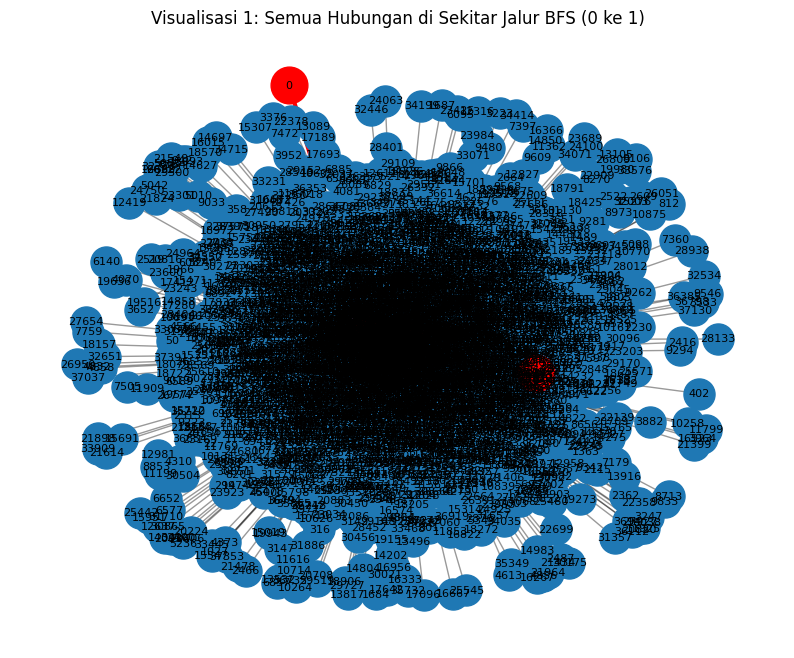

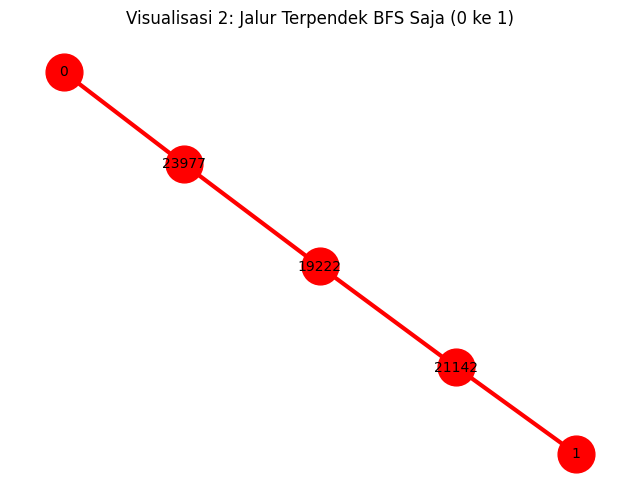

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert dictionary 'graph' menjadi graph NetworkX
G = nx.Graph(graph)

if result_path['found'] and result_path['path'] is not None:

    path_nodes = result_path['path']
    path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))

    # ==============================
    # VISUALISASI 1: Semua hubungan di sekitar jalur
    # ==============================
    neighborhood_nodes = set(path_nodes)
    for node in path_nodes:
        if node in G:
            neighborhood_nodes.update(G.neighbors(node))

    sub_path_G = G.subgraph(neighborhood_nodes)

    plt.figure(figsize=(10, 8))
    pos1 = nx.spring_layout(sub_path_G, seed=42)

    # Semua edge
    nx.draw_networkx_edges(sub_path_G, pos1, alpha=0.4)

    # Semua node
    nx.draw_networkx_nodes(sub_path_G, pos1, node_size=500)

    # Label semua node
    nx.draw_networkx_labels(sub_path_G, pos1, font_size=8)

    # Sorot jalur terpendek
    nx.draw_networkx_edges(
        sub_path_G,
        pos1,
        edgelist=path_edges,
        width=3,
        edge_color='red'
    )

    nx.draw_networkx_nodes(
        sub_path_G,
        pos1,
        nodelist=path_nodes,
        node_size=700,
        node_color='red'
    )

    plt.title(f"Visualisasi 1: Semua Hubungan di Sekitar Jalur BFS ({start_node} ke {target_node})")
    plt.axis("off")
    plt.show()

    # ==============================
    # VISUALISASI 2: Jalur terpendek saja
    # ==============================
    path_graph = G.subgraph(path_nodes)

    plt.figure(figsize=(8, 6))
    pos2 = nx.spring_layout(path_graph, seed=42)

    # Edge jalur saja
    nx.draw_networkx_edges(
        path_graph,
        pos2,
        edgelist=path_edges,
        width=3,
        edge_color='red'
    )

    # Node jalur saja
    nx.draw_networkx_nodes(
        path_graph,
        pos2,
        node_size=700,
        node_color='red'
    )

    # Label node
    nx.draw_networkx_labels(
        path_graph,
        pos2,
        font_size=10
    )

    plt.title(f"Visualisasi 2: Jalur Terpendek BFS ({start_node} ke {target_node})")
    plt.axis("off")
    plt.show()

else:
    print("Jalur tidak ditemukan sehingga tidak dapat divisualisasikan.")